In [1]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = '35'
from functionsgpu_fast import *

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import pickle
torch.set_default_device('cuda:1')
device = torch.device('cuda:1')

import warnings
warnings.filterwarnings("ignore")
tslen = 100
gamma_t = np.linspace(0, 1, tslen)

## Loading Data

In [7]:
data_ntu = np.load('/mnt/sdb/arafat/activity_recognition/data/data_ntu.pkl',allow_pickle=True)

## Resampling and Getting into Kendall Shape Space

In [10]:
betas_resampled = process_kinematic(data_ntu, gamma_t)
print(len(betas_resampled))

with open('aligned_data/betas_resampled_kendall{}.pkl'.format(tslen), 'wb') as f:
    pickle.dump(betas_resampled, f)

345


In [9]:
betas_all_arr = np.array(betas_resampled)
print(betas_all_arr.shape)

(345, 25, 3, 100)


## Getting frechet mean

  0%|          | 0/40 [00:00<?, ?it/s]

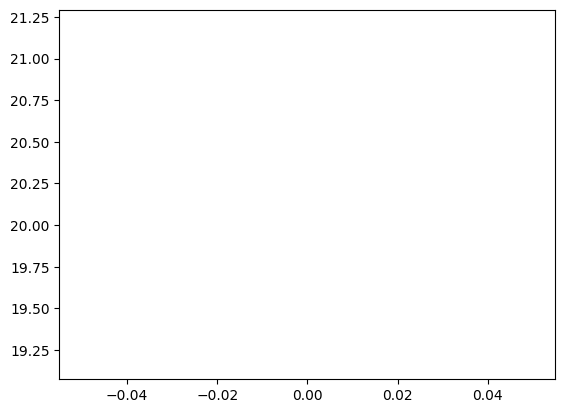

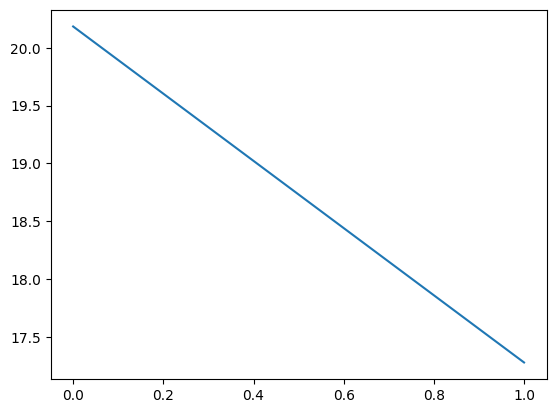

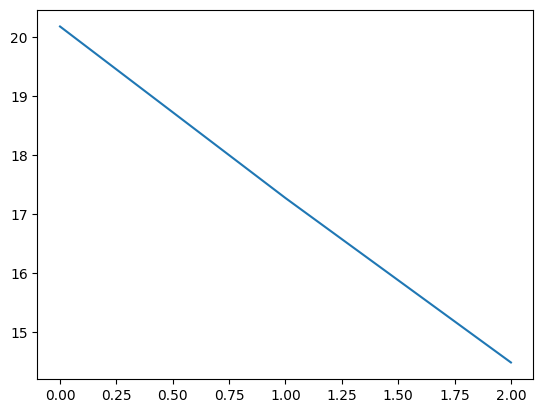

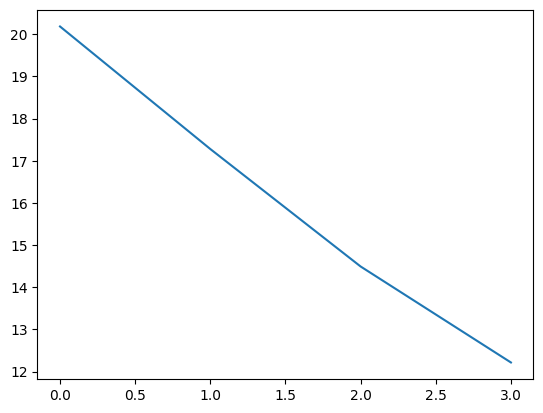

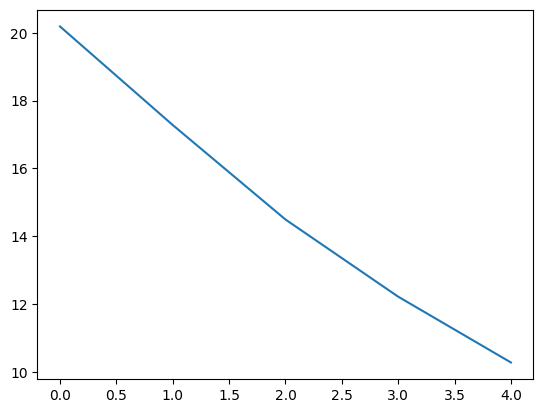

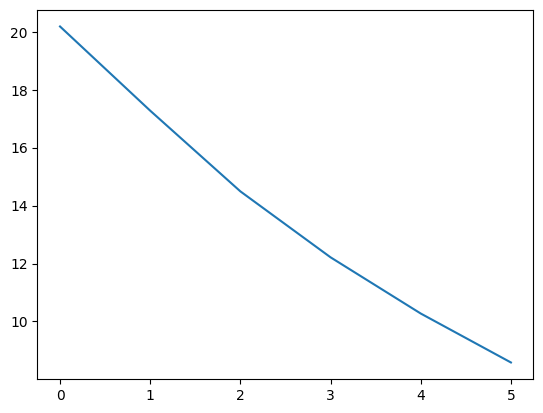

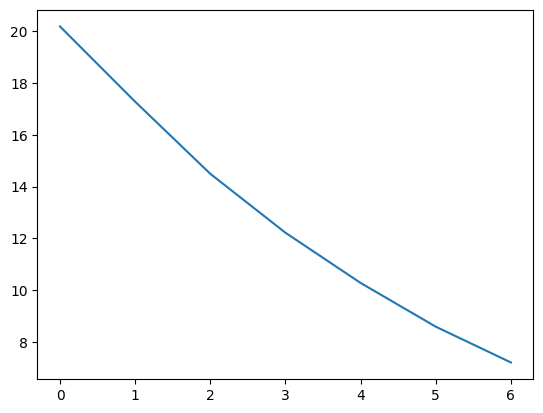

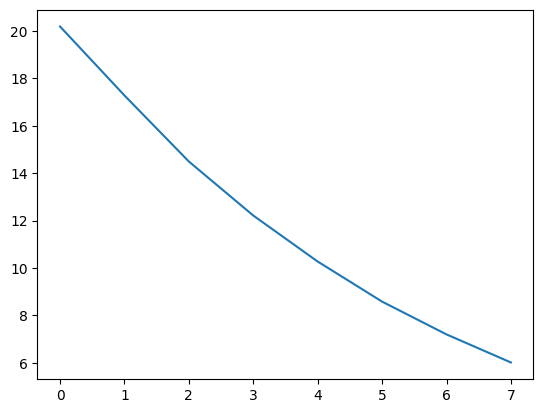

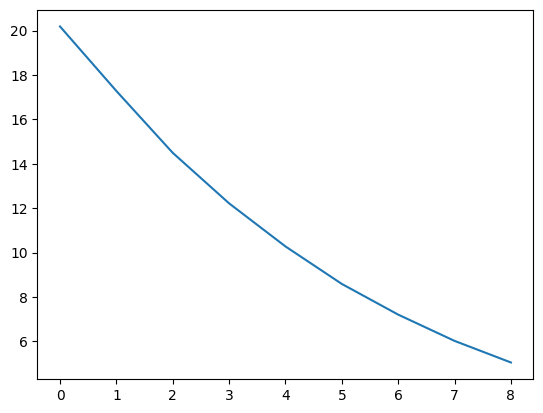

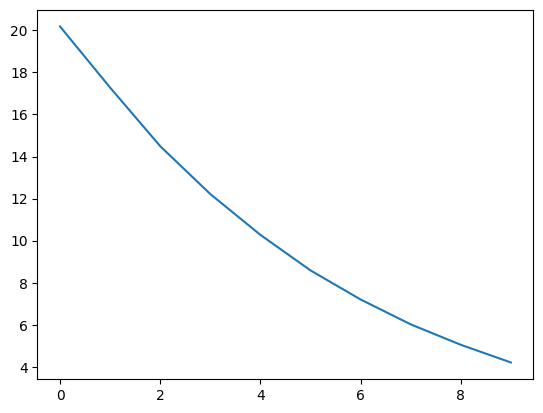

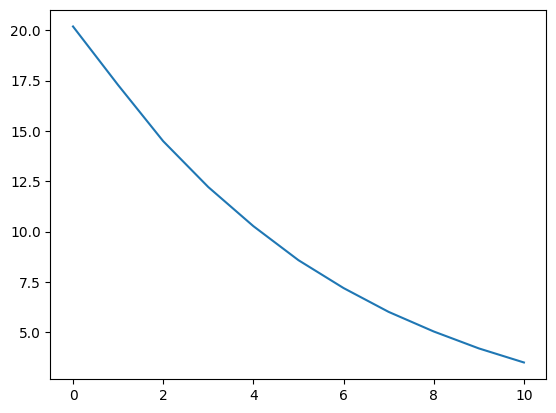

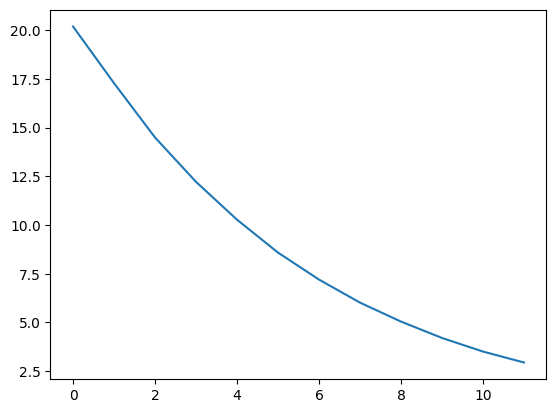

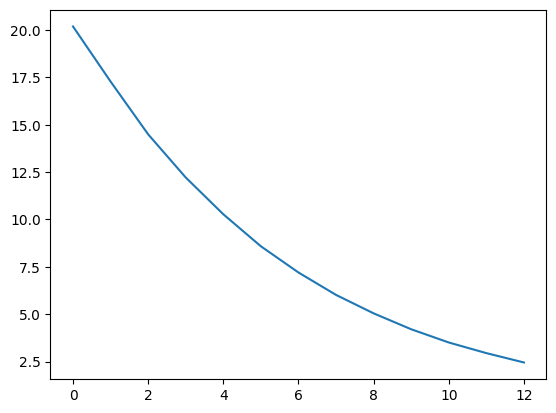

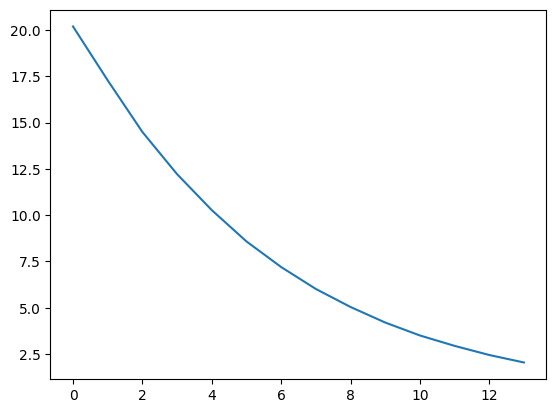

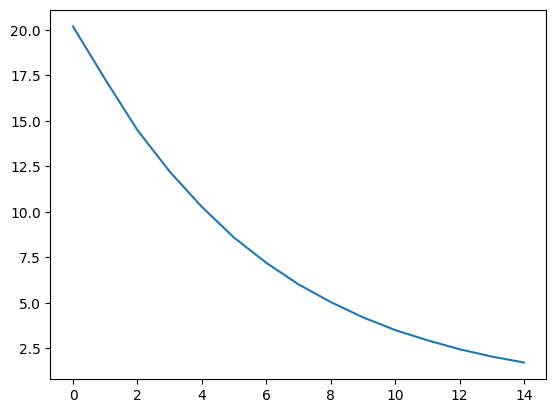

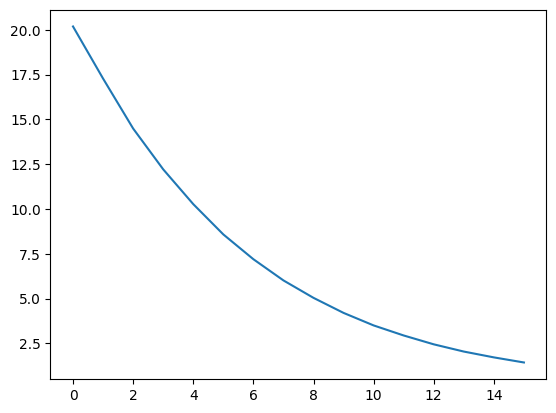

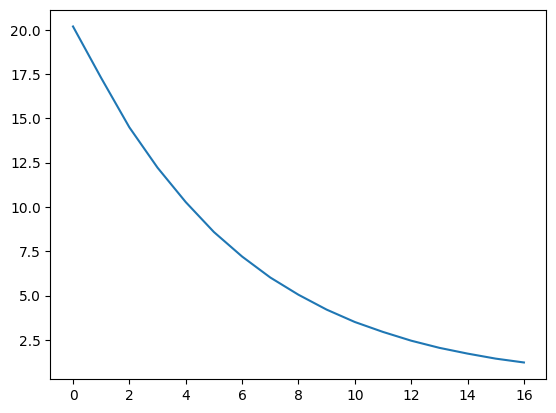

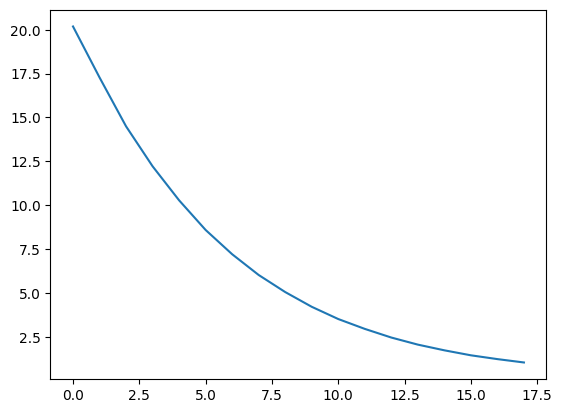

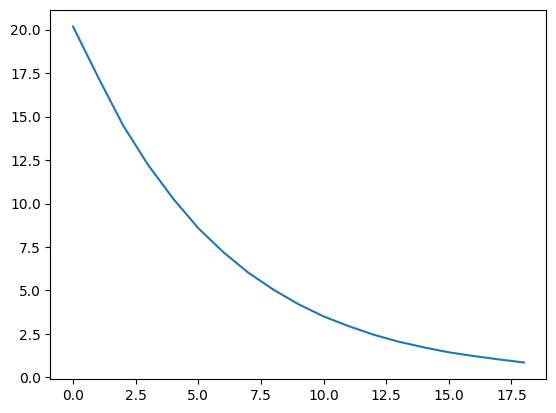

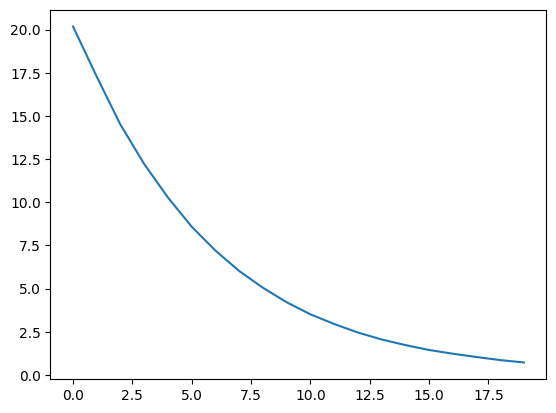

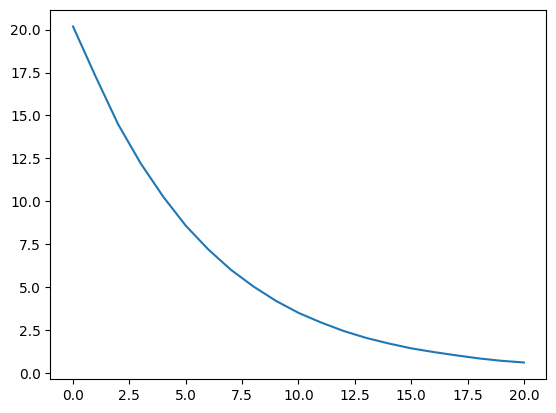

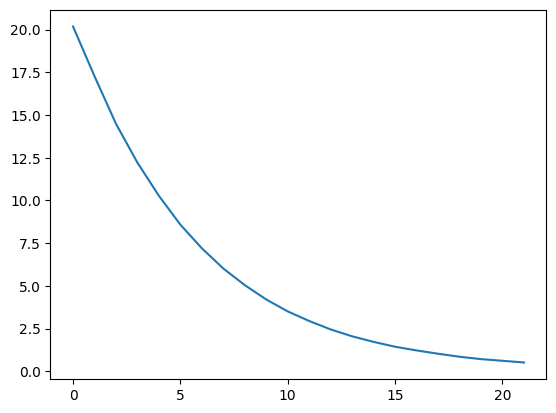

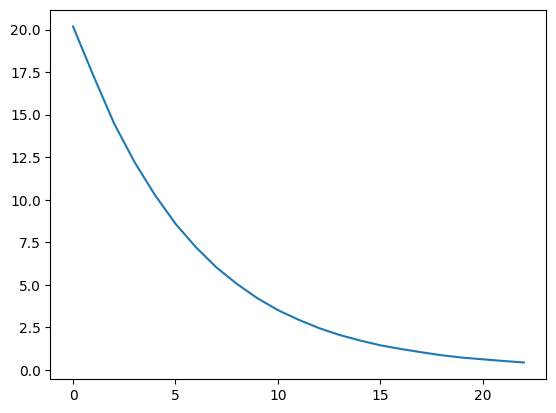

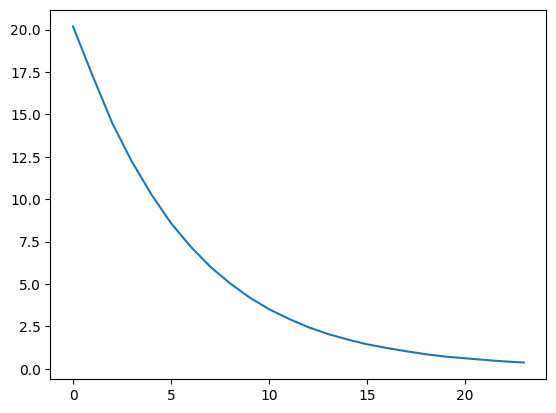

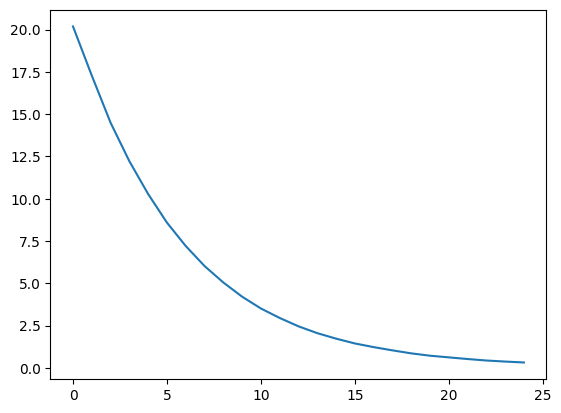

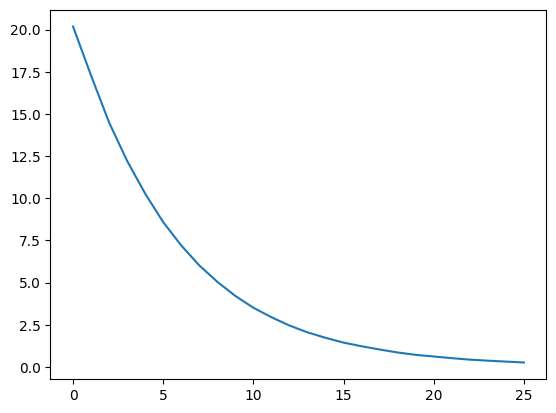

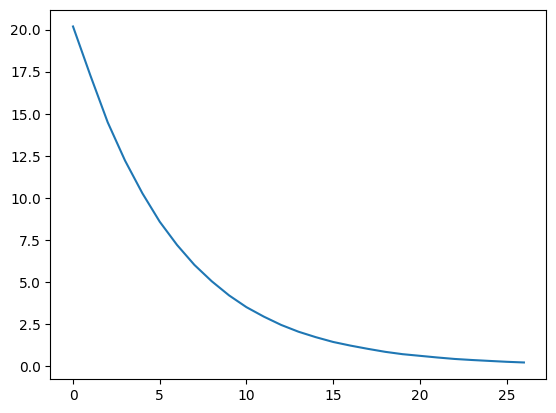

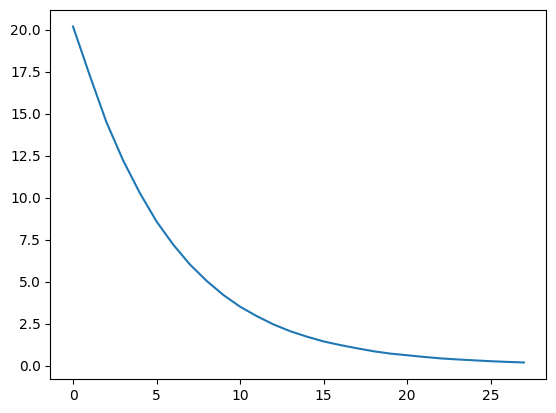

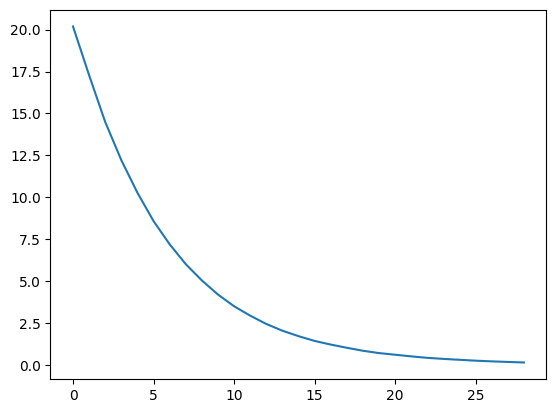

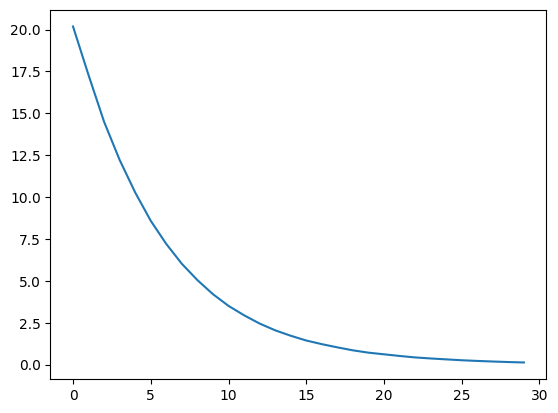

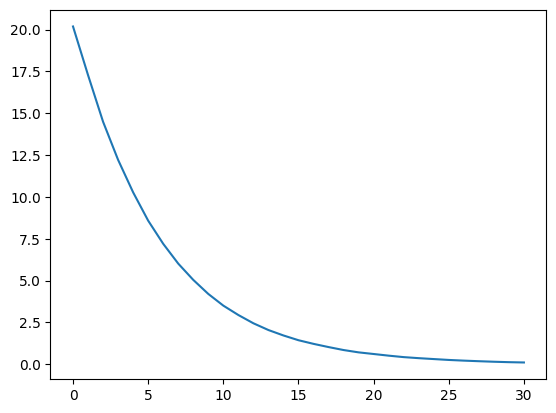

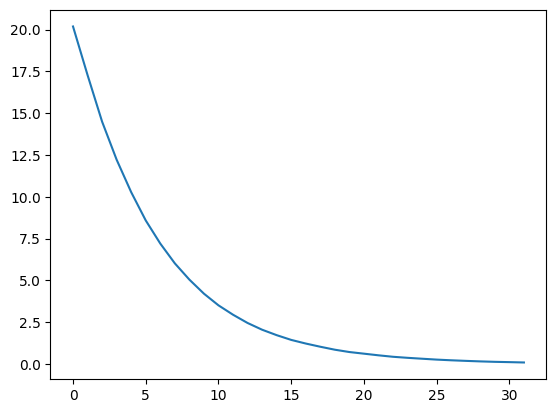

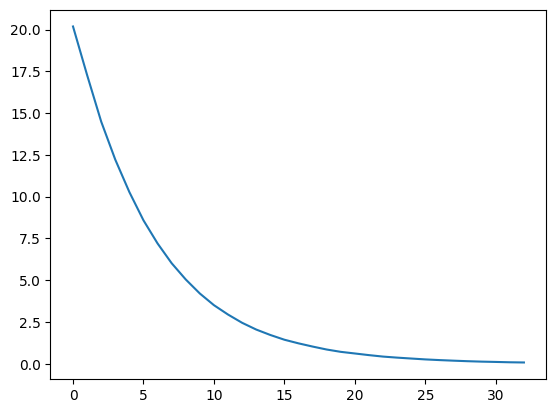

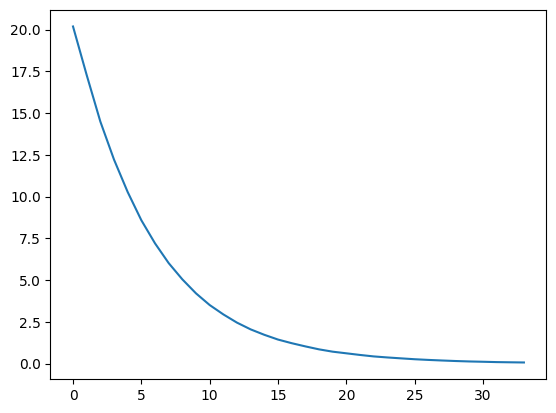

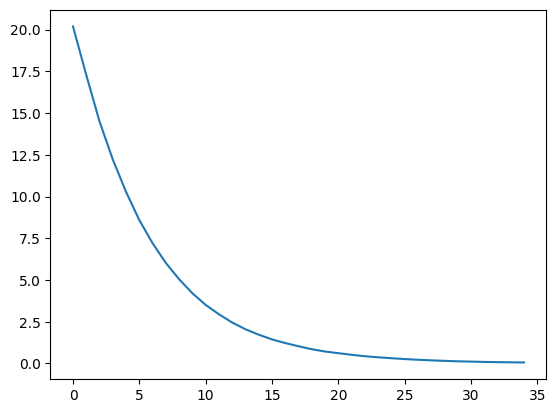

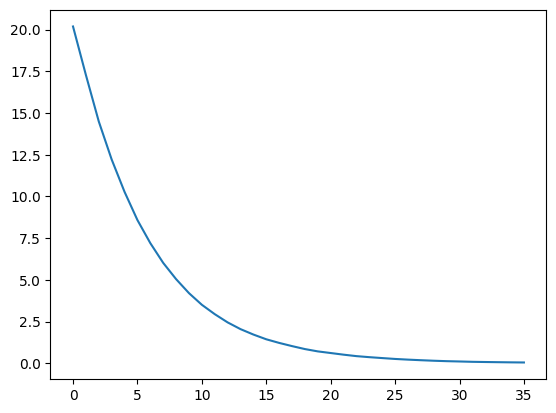

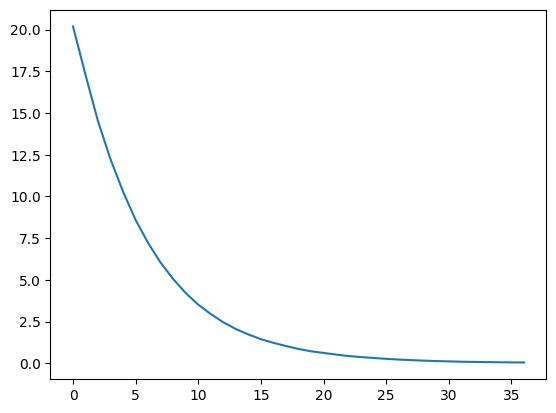

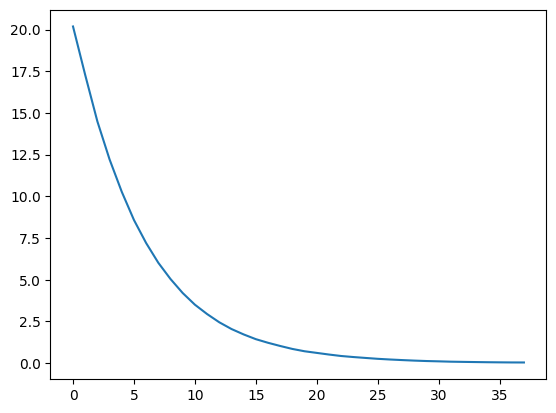

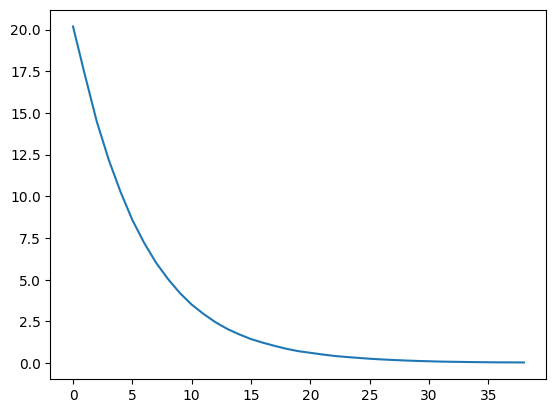

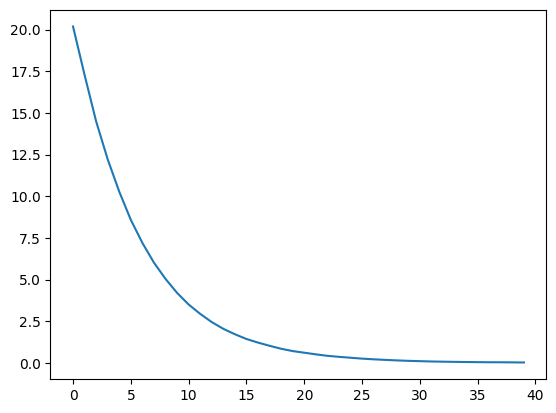

In [12]:
%matplotlib inline
mu_init = betas_all_arr[np.random.choice(range(len(betas_all_arr)))]
mu_all, betas_aligned_all, gammas_all, tangent_vec_all, history_all = frechet(betas_resampled, gamma_t, mu_init, iterations=40)

## Plotting trajectories of a single landmark

In [2]:
def plot_traj(betas_resampled, betas_aligned, gamma_t, gammas, mu):

    fig, axs = plt.subplots(1, 3, figsize=(3*10, 6))
    
    N = len(betas_resampled)
    
    for n in range(N):
    
      axs[0].plot(gamma_t, betas_resampled[n][0,0,:])
      axs[1].plot(gamma_t, betas_aligned[n][0,0,:])
      axs[2].plot(gamma_t, gammas[n])

    axs[1].plot(gamma_t, mu[0,0,:], color='black',linewidth=4)
    
    plt.tight_layout()

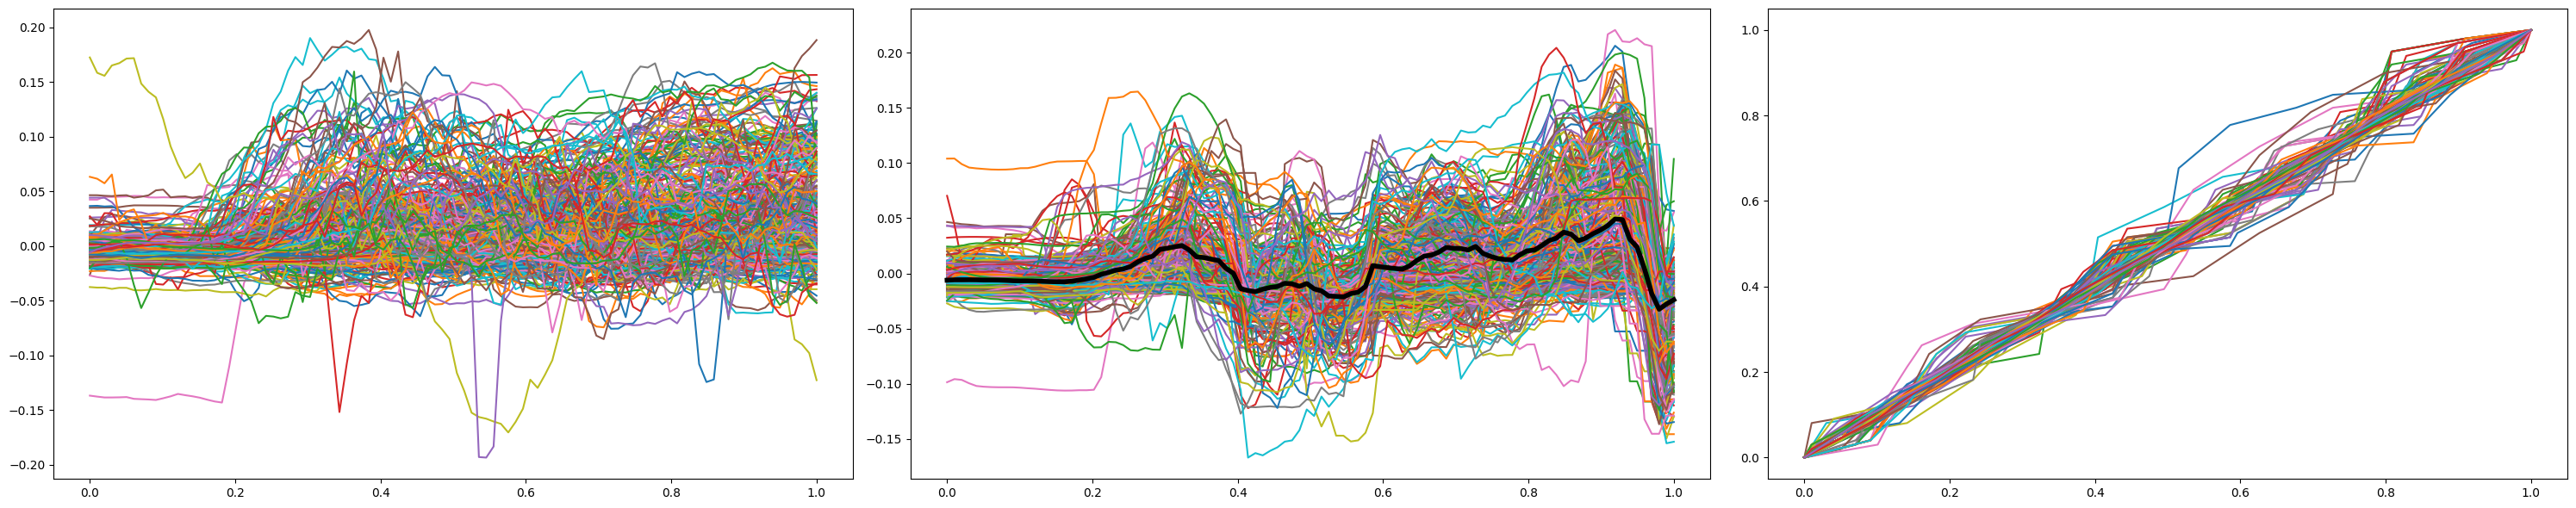

In [17]:
plot_traj(betas_resampled, betas_aligned_all, gamma_t, gammas_all, mu_all)

## Saving and loading

In [18]:
def saving(betas_aligned, mu, gammas, tangent_vecs, filename, tslen):
    
    with open('{}/betas_aligned{}.pkl'.format(filename, tslen), 'wb') as f:
        pickle.dump(betas_aligned, f)
    with open('{}/mu{}.pkl'.format(filename, tslen), 'wb') as f:
        pickle.dump(mu, f)
    with open('{}/gammas{}.pkl'.format(filename, tslen), 'wb') as f:
        pickle.dump(gammas, f)
    with open('{}/tangent_vecs{}.pkl'.format(filename, tslen), 'wb') as f:
        pickle.dump(tangent_vecs, f)

In [19]:
saving(betas_aligned_all, mu_all, gammas_all, tangent_vec_all, 'aligned_data',tslen)

In [3]:
# #loading
def loading(filename, tslen):
    with open('{}/betas_aligned{}.pkl'.format(filename, tslen), 'rb') as f:
        betas_aligned = pickle.load(f)
    with open('{}/mu{}.pkl'.format(filename, tslen), 'rb') as f:
        mu = pickle.load(f)
    with open('{}/tangent_vecs{}.pkl'.format(filename, tslen), 'rb') as f:
        tangent_vec_all = pickle.load(f)
    with open('{}/gammas{}.pkl'.format(filename, tslen), 'rb') as f:
        gammas_all = pickle.load(f)
    with open('{}/betas_resampled_kendall{}.pkl'.format(filename, tslen), 'rb') as f:
        betas_resampled = pickle.load(f)
    return betas_aligned, mu, tangent_vec_all, gammas_all, betas_resampled

In [6]:
# betas_aligned_all, mu_all, tangent_vec_all, gammas_all, betas_resampled = loading('aligned_data',tslen)
# len(betas_aligned_all)

In [7]:
# plot_traj(betas_resampled, betas_aligned_all, gamma_t, gammas_all, mu_all)